## 딥러닝 비지도학습

### 1. 차원축소

In [ ]:
'''
비지도학습 가운데 차원축소는
고차원의 데이터를 더 적은 수의 특성으로 요약하여
데이터의 구조를 이해하고 시각화할 수 있도록 돕는 기법

데이터의 차원을 낮춰 중요 정보를 유지하고 복잡성을 줄이는데,
이를 통해 머신러닝 모델의 학습 속도 향상과 과적합 완화를 달성할 수 있다.

이는 차원의 저주와도 연관되어있는데, 
데이터에서 높은 차원을 가질수록 데이터가 희소해지고 파악하기 힘들어지는 현상이다.
'''

##### 1-1. 주성분 분석

In [ ]:
'''
주성분 분석

주성분 분석은 데이터의 차원을 낮추는 과정에서
데이터의 분산을 최대한 보존하는 축(주성분)을 찾아 데이터를 변환하고
상관된 변수를 결합해 중복정보를 줄이는 기법. 
'''

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# 데이터 로드
cancer = load_breast_cancer()   # 사이킷런 내장 데이터셋

# DataFrame으로 변환 (타겟 값 제외)
data = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# 데이터 정보 확인 - 칼럼이 30개...
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [3]:
# 데이터 통계량 확인
data.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
from sklearn.preprocessing import StandardScaler

# 데이터 스케일링
scaler      = StandardScaler()
scaled_data = scaler.fit_transform(data)

# 스케일링된 데이터 데이터 프레임 변환
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)
# 데이터 확인
scaled_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [5]:
from sklearn.decomposition import PCA

# pca 모델 생성 및 적용
pca = PCA(n_components=10)   # 주성분을 10개로 설정
principal_components = pca.fit_transform(scaled_df)     # PCA 적용

# 결과
print(principal_components[:10])

[[ 9.19283683  1.94858307 -1.12316616 -3.6337309   1.19511012  1.41142445
   2.15936987 -0.39840723 -0.15711836 -0.87740188]
 [ 2.3878018  -3.76817174 -0.52929269 -1.11826386 -0.62177498  0.02865635
   0.01335809  0.24098846 -0.71190482  1.10699494]
 [ 5.73389628 -1.0751738  -0.55174759 -0.91208267  0.1770859   0.54145215
  -0.66816648  0.09737374  0.02406564  0.4542754 ]
 [ 7.1229532  10.27558912 -3.23278955 -0.15254703  2.9608784   3.05342182
   1.4299107   1.05956524 -1.40543967 -1.11697527]
 [ 3.93530207 -1.94807157  1.38976673 -2.94063935 -0.5467474  -1.22649464
  -0.93621255  0.63637606 -0.26380546  0.37770447]
 [ 2.38024715  3.9499289  -2.93487679 -0.94103687  1.05604193 -0.45103865
   0.49044512 -0.16544388 -0.1334731  -0.53043122]
 [ 2.23888331 -2.69003128 -1.63991293 -0.14933989 -0.04035952 -0.12894843
  -0.30156745  0.08369819 -0.08002457  0.21914335]
 [ 2.1432985   2.34024401 -0.87194726  0.12704286  1.42743667 -1.25703919
   0.97409985 -0.65333826  0.24818365  1.00058612]


In [ ]:
# 각 주성분이 설명하는 분산 비율 확인
print('설명 분산 비율:', pca.explained_variance_ratio_, sep='\n')

설명 분산 비율:
[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734 0.01588724 0.01389649 0.01168978]


In [10]:
# 누적 분산 비율 확인
print('누적 분산 비율:', pca.explained_variance_ratio_.cumsum(), sep='\n')

누적 분산 비율:
[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881]


In [ ]:
'''
pca.fit() 했을 때

pca.explained_variance_ratio_
pca.components_
pca.singular_values_

이 세놈이 알아서 생김
'''

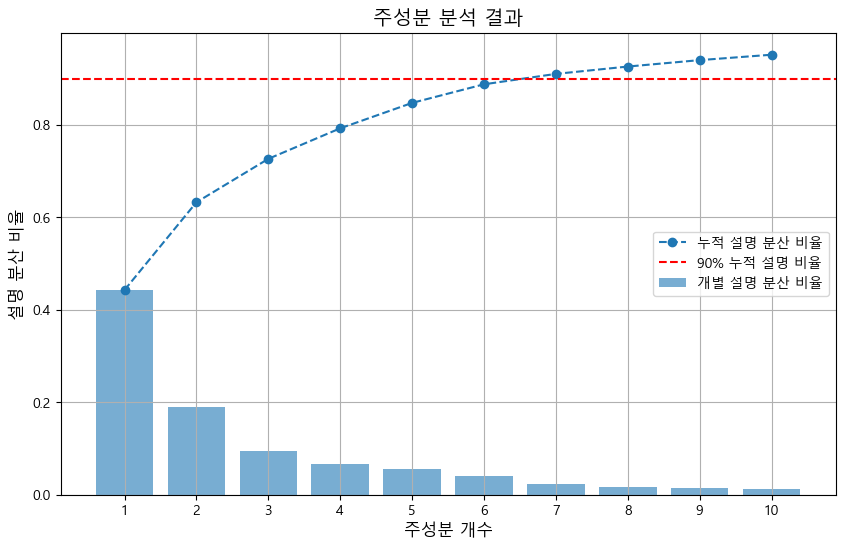

In [11]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 폰트 설정 (예: 'Malgun Gothic'은 윈도우에서 사용 가능)
# 맥일 경우 아래 코드 활성화
#plt.rcParams['font.family'] = 'AppleGothic'
# 윈도우일 경우 아래 코드 활성화
plt.rcParams['font.family'] = 'Malgun Gothic'

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio.cumsum(), marker='o', linestyle='--', label='누적 설명 분산 비율')
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.6, label='개별 설명 분산 비율')

# 그래프 꾸미기
plt.title('주성분 분석 결과', fontsize=14)
plt.xlabel('주성분 개수', fontsize=12)
plt.ylabel('설명 분산 비율', fontsize=12)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% 누적 설명 비율')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.legend()
plt.grid()
plt.show()

In [ ]:
# 시각화 결과를 보고 pca 재진행 
pca = PCA(n_components=7)       # 위 결과를 보면 7부터 90퍼센터 설명력을 가지므로
principal_components = pca.fit_transform(scaled_df)

# 설명분산 재확인
print('설명 분산 비율:', pca.explained_variance_ratio_, sep='\n')

# 누적 분산 비율 확인 - 마지막 요소에서 91퍼센트 설명력
print('누적 분산 비율:', pca.explained_variance_ratio_.cumsum(), sep='\n')

설명 분산 비율:
[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]
누적 분산 비율:
[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953 ]


##### 1-2. t-SNE

In [ ]:
'''
t-SNE(t-분포 확률적 임베딩)은 데이터의 국소적 구조를 보존하는데 중점을 두는 차원 축소 기법

고차원 관계 정의
고차원 데이터 점들간의 유사성을 확률로 나타내어 가우시안 분포를 계산해 점들 간 관계를 구축

저차원 관계 정의
저차원에서도 점들 간의 유사성을 확률로 계산하고 t-분포를 사용해 저차원에서 점들이
뭉치는 문제(Crowding Problem)를 완화한다.

확률 분포 차이 최소화
고차원과 저차원에서 계산된 확률 분포 간의 차이를 KL발산을 통해 최소화하고
반복적으로 최적화한다.
'''

In [25]:
import pandas as pd

# GitHub에서 데이터 로드
url = "https://raw.githubusercontent.com/sventura/315-code-and-datasets/master/data/olive_oil.csv"
olive = pd.read_csv(url)

# 데이터 확인
olive.head()

,area,region,palmitic,palmitoleic,stearic,oleic,linoleic,linolenic,arachidic,eicosenoic
0,1,1,1075,75,226,7823,672,36,60,29
1,1,1,1088,73,224,7709,781,31,61,29
2,1,1,911,54,246,8113,549,31,63,29
3,1,1,966,57,240,7952,619,50,78,35
4,1,1,1051,67,259,7771,672,50,80,46


In [ ]:
# 불필요 컬럼 삭제
olive.drop(['region'], axis=1, inplace=True)

# 데이터 분할
x = olive.drop(['area'], axis=1)
y = olive['area']

x.head()

,palmitic,palmitoleic,stearic,oleic,linoleic,linolenic,arachidic,eicosenoic
0,1075,75,226,7823,672,36,60,29
1,1088,73,224,7709,781,31,61,29
2,911,54,246,8113,549,31,63,29
3,966,57,240,7952,619,50,78,35
4,1051,67,259,7771,672,50,80,46


In [ ]:
# 정규화 라이브러리 호출
from sklearn.preprocessing import StandardScaler

# 데이터 정규화
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 정규화된 데이터 데이터프레임으로 변환 - transform()은 항상 넘파이 array를 반환함
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)
x_scaled

,palmitic,palmitoleic,stearic,oleic,linoleic,linolenic,arachidic,eicosenoic
0,-0.930520,-0.974183,-0.078049,1.260932,-1.271825,0.317340,0.086416,0.903884
1,-0.853343,-1.012316,-0.132526,0.979767,-0.822501,-0.068541,0.131848,0.903884
2,-1.904132,-1.374576,0.466720,1.976178,-1.778859,-0.068541,0.222711,0.903884
3,-1.577616,-1.317377,0.303290,1.579093,-1.490303,1.397807,0.904189,1.330293
4,-1.073000,-1.126714,0.820820,1.132681,-1.271825,1.397807,0.995053,2.112044
...,...,...,...,...,...,...,...,...
567,0.286496,-0.306861,1.665212,0.439633,-0.785401,-1.689242,-2.185177,-1.014959
568,-1.019570,-0.497525,1.120443,1.056224,-0.702956,-1.689242,-2.185177,-0.943891
569,-1.316403,-0.688188,-0.513864,1.006897,-0.043399,-2.461005,-2.639496,-1.014959
570,-1.435136,-0.116198,0.575674,1.080888,-0.455622,-1.689242,-2.185177,-1.014959


In [27]:
from sklearn.manifold import TSNE

# 2차원 t-SNE모델 생성 및 적용
tsne = TSNE(n_components=2, random_state= 42)
x_tsne = tsne.fit_transform(x_scaled)
x_tsne

array([[ 9.432482 ,  4.343607 ],
       [ 9.593806 ,  4.0052476],
       [ 9.917305 ,  5.7850037],
       ...,
       [42.575977 ,  5.348997 ],
       [40.478073 ,  2.7124789],
       [38.76349  ,  4.4627275]], dtype=float32)

c:\Users\16Z90P\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


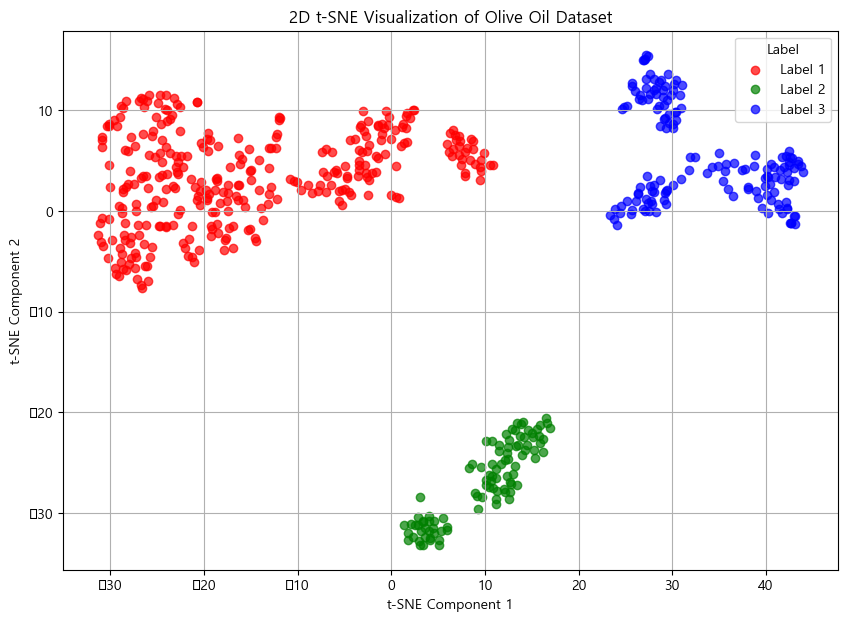

In [31]:
import matplotlib.pyplot as plt

# t-SNE 결과 시각화
plt.figure(figsize=(10, 7))

# 각 레이블별 산점도 생성
plt.scatter(x_tsne[y == 1, 0], x_tsne[y == 1, 1], color='red', alpha=0.7, label='Label 1')
plt.scatter(x_tsne[y == 2, 0], x_tsne[y == 2, 1], color='green', alpha=0.7, label='Label 2')
plt.scatter(x_tsne[y == 3, 0], x_tsne[y == 3, 1], color='blue', alpha=0.7, label='Label 3')

# 범례 추가
plt.legend(title="Label", loc='upper right')
plt.title('2D t-SNE Visualization of Olive Oil Dataset')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()


In [32]:
# t-SNE 3차원 모델 생성 및 적용
tsne_3d = TSNE(n_components=3, random_state=42)
x_tsne_3d = tsne_3d.fit_transform(data_scaled)  # 표준화된 데이터 사용
x_tsne_3d

array([[ 4.2075953,  3.1357248,  1.8631938],
       [ 3.9546423,  2.970482 ,  1.7509651],
       [ 4.946286 ,  3.1367638,  2.841948 ],
       ...,
       [14.899834 , -4.0063734,  5.9199038],
       [13.295584 , -4.3591995,  4.2387824],
       [11.919965 , -4.797139 ,  5.268826 ]], dtype=float32)

c:\Users\16Z90P\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


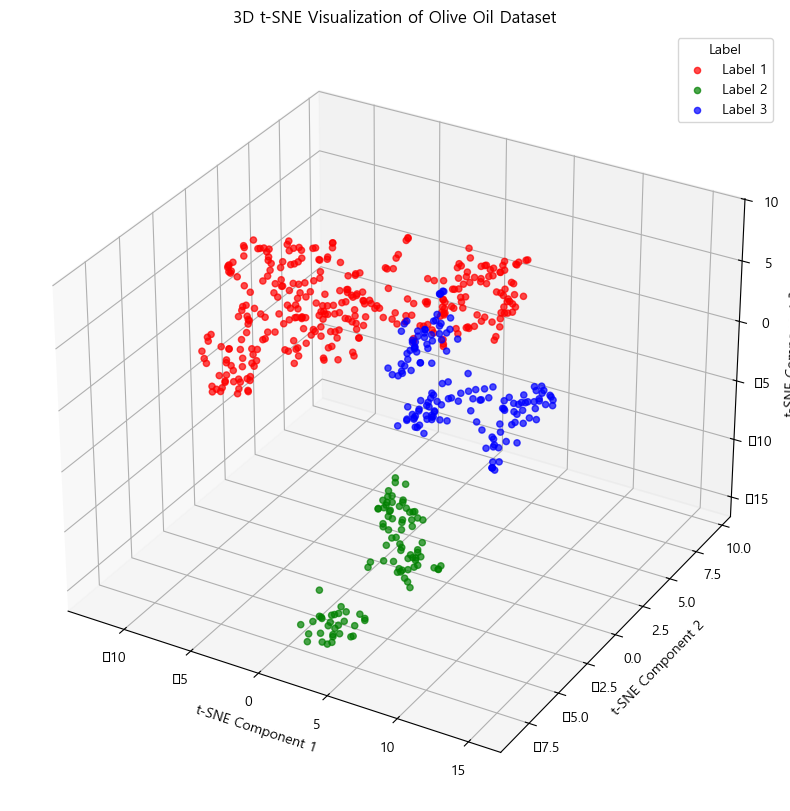

In [34]:
# 3D 시각화 라이브러리 호출
from mpl_toolkits.mplot3d import Axes3D

# 3D 시각화
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 레이블별로 산점도 추가
ax.scatter(x_tsne_3d[y == 1, 0], x_tsne_3d[y == 1, 1], x_tsne_3d[y == 1, 2], color='red', alpha=0.7, label='Label 1')
ax.scatter(x_tsne_3d[y == 2, 0], x_tsne_3d[y == 2, 1], x_tsne_3d[y == 2, 2], color='green', alpha=0.7, label='Label 2')
ax.scatter(x_tsne_3d[y == 3, 0], x_tsne_3d[y == 3, 1], x_tsne_3d[y == 3, 2], color='blue', alpha=0.7, label='Label 3')

# 그래프 제목 및 축 설정
ax.set_title('3D t-SNE Visualization of Olive Oil Dataset')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')
ax.legend(title="Label", loc='upper right')
plt.show()

### 2. 군집

In [ ]:
'''
군집은 비지도 학습의 대표적인 기법 중 하나로, 
정답이 없는 상태에서 데이터 간의 유사성을 기반으로
비슷한 속성을 가진 데이터들을 하나의 그룹으로 묶는 방법이다.

차원 축소 기법과 결합해 고차원 데이터들의 효과적인 시각화와 직관적인 이해를 돕는데 유리하다
'''

#### 2-1. k-means 군집화

In [ ]:
'''
k-means 군집화는 서로 비슷한 데이터 포인트를 하나의 군집으로 묶어
각 군집이 데이터의 공통적인 특성을 반영한다.

군집화를 위해 거리기반 계산을 활용하며,
주어진 데이터에서 각 군집의 중심점에 할당하여 군집을 형성한다.

군집이 비 구형이거나 이상치가 있는 경우 성능이 저하된다.
'''

In [ ]:
'''
군집의 개수는 사전에 설정해야 하며, 설정된 K값에 따라 결과가 달라진다

적절한 k값의 선정을 위해 엘보우 기법이나 실루엣 분석 등의 기법을 사용함
    엘보우 기법 - 클러스터 수를 바꿔가며 총 거리를 보고 조절하는 시행착오법
    실루엣 분석 - 각 데이터 포인트가 자신의 클러스터 내에서 얼마나 잘 속해있는지 수치화
'''

In [ ]:
'''
k-means 동작 방식
    1. k값 선정
    2. K만큼 군집화
    3. 각 군집의 무게중심 계산
    4. 군집화 평가 - WCSS, 실루엣 계수 등 
'''

#### 2-2. DBSCAN(밀도 기반) 군집화